In [1]:
import pandas as pd
import sqlite3

In [2]:
df = pd.read_csv(r"C:\Users\jayal\Documents\Marketing_Attribution_Project\Cleaned_attribution_data.csv")

In [3]:
conn = sqlite3.connect(r"C:\Users\jayal\Documents\Marketing_Attribution_Project\attribution.db")

In [4]:
df.to_sql('attribution',conn,if_exists='replace',index=False)
print("Data loaded successfully!")
print(f"Total rows loaded:{len(df)}")


Data loaded successfully!
Total rows loaded:586737


In [13]:
#window function: user journey sequencing
query="""
SELECT cookie,time,channel,row_number() OVER (PARTITION by cookie ORDER by time) as touch_number FROM attribution LIMIT 20;"""
df2 = pd.read_sql_query(query,conn)
df2.head()

,cookie,time,channel,touch_number
0,00000FkCnDfDDf0iC97iC703B,2018-07-03T13:02:11Z,Instagram,1
1,00000FkCnDfDDf0iC97iC703B,2018-07-17T19:15:07Z,Online Display,2
2,00000FkCnDfDDf0iC97iC703B,2018-07-24T15:51:46Z,Online Display,3
3,00000FkCnDfDDf0iC97iC703B,2018-07-29T07:44:51Z,Online Display,4
4,0000nACkD9nFkBBDECD3ki00E,2018-07-03T09:44:57Z,Paid Search,1


In [14]:
#First click attribution
query="""
with journey as(

      select cookie,channel,

	  row_number() over (PARTITION by cookie order by time) as touch_number

	  from attribution

)

select channel,count(*) as first_click_count

from journey

where touch_number=1

group by channel;
"""
result = pd.read_sql_query(query,conn)
result.head()

,channel,first_click_count
0,Facebook,66848
1,Instagram,28618
2,Online Display,34250
3,Online Video,34182
4,Paid Search,76210


In [ ]:
#14th June 2026

In [5]:
#linear attribution
query1="""
with journey as (
   select cookie, channel,
   count(*) over (partition by cookie) as total_touches
   from attribution
)
select channel,
round(sum(1.0/total_touches),2) as linear_attribution_score
from journey
group by channel
order by linear_attribution_score desc;
"""
df3 =  pd.read_sql_query(query1,conn)
print(df3)

          channel  linear_attribution_score
0     Paid Search                  74560.28
1        Facebook                  67311.76
2    Online Video                  35199.74
3  Online Display                  34168.10
4       Instagram                  28868.12


In [6]:
#last click attribution
query2="""
with journey as (
      select cookie,channel,
	  row_number() over (partition by cookie order by time desc) as touch_number
	  from attribution
)
select channel,count(*) as last_click_count
from journey
where touch_number=1
group by channel
order by last_click_count desc;
"""
df4 = pd.read_sql_query(query2,conn)
print(df4)

          channel  last_click_count
0     Paid Search             71647
1        Facebook             69113
2    Online Video             35135
3  Online Display             34611
4       Instagram             29602


In [ ]:
#15th June 2026

In [6]:
#Total Touchpoints per user
query5="""
select cookie, count(*) as total_touches
from attribution
group by cookie
order by total_touches DESC
limit 10;
"""
df5 = pd.read_sql_query(query5,conn)
print(df5)

                      cookie  total_touches
0  FDkCnkBiB7FiE9oBDC7ifn7kF            134
1  AiknC7ED3DnEo3EnFfk7ABok3            126
2  A7Boi393DfEnnf09FiA0kkE9D            120
3  Dh3F3hCf0inffCnD7fDfFokBo            106
4  kn3nokni7B9k39nk3oinhAn3B            105
5  ooAEBhf03A70B70fn9AF0n9kk            104
6  DfFff0f9BD0Anh0kDh770D9Fo             97
7  93k3n0BDA3B3ED9AADkEEn9An             81
8  ADh39nh0nk3BCof7i7k0i9hDf             77
9  FBAfi0nkAB7oAiiACfBC7non0             76


In [7]:
#Channel Conversion Rate Analysis
query6="""
select channel,
count(*) as total_touches,
sum(conversion) as total_conversions,
round(sum(conversion)*100.0/count(*),2) as conversion_rate
from attribution
group by channel
order by conversion_rate desc;
"""
df6 = pd.read_sql_query(query6,conn)
print(df6)

          channel  total_touches  total_conversions  conversion_rate
0        Facebook         175741               5301             3.02
1    Online Video         113302               3408             3.01
2  Online Display          71053               2139             3.01
3     Paid Search         151440               4547             3.00
4       Instagram          75201               2244             2.98


In [ ]:
#16th June 2026


In [5]:
#conversion value by channel
query7="""
select channel,
sum(conversion_value) as total_revenue,
round(avg(conversion_value),2) as avg_revenue
from attribution
group by channel
order by total_revenue desc;
"""
df7=pd.read_sql_query(query7,conn)
print(df7)

          channel  total_revenue  avg_revenue
0        Facebook        33143.5         0.19
1     Paid Search        28331.5         0.19
2    Online Video        21418.0         0.19
3       Instagram        14039.5         0.19
4  Online Display        13298.5         0.19


In [6]:
#Average Touchpoints before conversions
query8="""
select round(avg(total_touches),2) as avg_touches_before_conversion
from(
  select cookie, count(*) as total_touches
  from attribution
  where conversion =1 
  group by cookie
);
"""
df8 = pd.read_sql_query(query8,conn)
print(df8)

   avg_touches_before_conversion
0                            1.0


In [ ]:
#17th June 2026

In [6]:
#Top Performing channels
query9="""
select channel,
sum(conversion) as total_conversions,
sum(conversion_value) as total_conversion_value
from attribution
group by channel
order by total_conversions DESC;
"""
df9 = pd.read_sql_query(query9,conn)
print(df9)

          channel  total_conversions  total_conversion_value
0        Facebook               5301                 33143.5
1     Paid Search               4547                 28331.5
2    Online Video               3408                 21418.0
3       Instagram               2244                 14039.5
4  Online Display               2139                 13298.5


In [7]:
#User journey length distribution
query10 = """
select total_touches, count(*) as number_of_users
from(select cookie, count(*) as total_touches from attribution group by cookie)
group by total_touches
order by total_touches;
"""
df10 = pd.read_sql_query(query10,conn)
print(df10)

    total_touches  number_of_users
0               1           123464
1               2            51880
2               3            24853
3               4            13106
4               5             7817
..            ...              ...
71            105                1
72            106                1
73            120                1
74            126                1
75            134                1

[76 rows x 2 columns]


In [ ]:
#18th June 2026

In [5]:
#Attribution Models Comparsion
comparison = pd.DataFrame({
    'channel':['Paid Search','Facebook','Online Video','Online Display','Instagram'],
    'First_Click':[76210,66848,34182,34250,28618],
    'Linear_Score':[74560.28,67311.76,35199.74,34168.10,28868.12],
    'Last_Click':[71647,69113,35135,34611,29602]
})
print(comparison)

          channel  First_Click  Linear_Score  Last_Click
0     Paid Search        76210      74560.28       71647
1        Facebook        66848      67311.76       69113
2    Online Video        34182      35199.74       35135
3  Online Display        34250      34168.10       34611
4       Instagram        28618      28868.12       29602


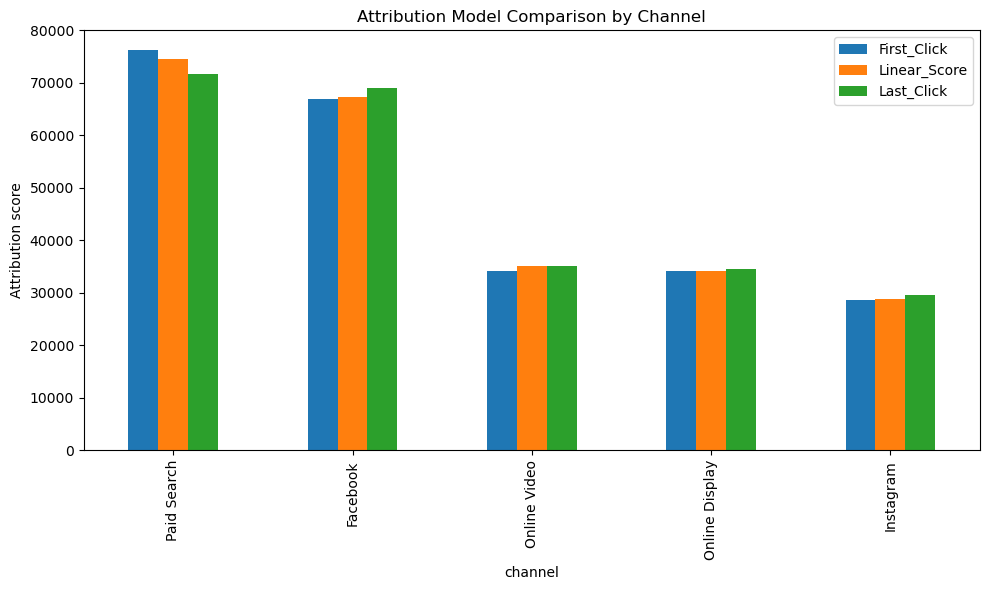

In [7]:
import matplotlib.pyplot as plt
comparison.plot(x='channel',kind='bar',figsize=(10,6))
plt.title('Attribution Model Comparison by Channel')
plt.ylabel('Attribution score')
plt.tight_layout()
plt.savefig('attribution_comparison.png')
plt.show()